# Comparação dos quatro modelos — horizonte de 30 dias

Espelha `horizonte_7dias/AMA_comparacao_modelos.ipynb`, porém para a bateria
de **30 dias**: carrega os `resultados_*_30d.pkl` (LR, MLP, RF re-treinados do
zero em `horizonte_30dias/`) e roda a inferência do **LSTM de 30 dias**
(`lstm_30_dias.pth`), re-rotulando com `ssd.create_class_labels(data, mask, 30)`
(versão correta, por lista — não reintroduz o bug do rótulo vazio para discos
de vida curta; ver `REVISAO.md` item 8.1).

Antes de comparar, o notebook **valida e relata**: (a) que a arquitetura
recriada carrega `lstm_30_dias.pth` de forma estrita (sem divergência de
shape); (b) que a partição de discos da inferência do LSTM coincide com a dos
tabulares de 30 dias. Se o `load_state_dict` falhar, o notebook **para e
relata** o erro exato (não carrega de forma não-estrita).

**Caveat (não comparar entre horizontes):** a prevalência de positivos em 30
dias (~8%) é ~4× a de 7 dias (~2%), o que infla F1/AP mecanicamente. Use estas
tabelas/figuras para comparar os modelos *dentro* do horizonte de 30 dias; para
7 dias, use o notebook de comparação oficial. Saídas com sufixo `_30d`.

> Pré-requisito: `lstm_30_dias.pth` deve estar em `horizonte_30dias/` e os três
> `resultados_*_30d.pkl` já gerados pelos notebooks de treino de 30 dias.

# Comparação dos Modelos (horizonte de 30 dias): LSTM × Regressão Logística × MLP × Random Forest

Carrega os resultados salvos pelos três notebooks de treinamento e gera
os gráficos comparativos: métricas agregadas, curvas ROC, curvas
Precisão-Recall, matrizes de confusão, histórico de perda do LSTM e
tempo de treinamento.

> **Dependências:** `numpy`, `matplotlib`, `scikit-learn`, `torch`  
> Arquivos necessários no mesmo diretório: `resultados_logistic_regression_30d.pkl`,
> `resultados_mlp_30d.pkl`, `resultados_random_forest_30d.pkl`, `lstm_30_dias.pth`,
> `data.pickle`, `mask.pickle`

In [1]:
import os
import sys

# --- Resolucao robusta de caminhos (independente do diretorio de trabalho) ---
def _encontra_raiz(inicio=None):
    """Sobe na arvore ate achar comum/ssd_utils.py."""
    d = os.path.abspath(inicio or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, 'comum', 'ssd_utils.py')):
            return d
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError('raiz do projeto (com comum/ssd_utils.py) nao encontrada')
        d = pai

PROJ_ROOT = _encontra_raiz()
COMUM_DIR = os.path.join(PROJ_ROOT, 'comum')
H7_DIR = os.path.join(PROJ_ROOT, 'horizonte_7dias')
H30_DIR = os.path.join(PROJ_ROOT, 'horizonte_30dias')
EXP_DIR = os.path.join(PROJ_ROOT, 'experimentos')
if COMUM_DIR not in sys.path:
    sys.path.insert(0, COMUM_DIR)
# ---------------------------------------------------------------------------

import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score,
)

DATA_DIR = COMUM_DIR        # data.pickle / mask.pickle (pasta comum/)
OUTPUT_DIR = H30_DIR        # resultados, checkpoint e figuras de 30 dias
SAVE_FIGS = True          # salva cada figura em PNG
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
COLORS = {'LSTM': '#1565C0', 'Logistic Regression': '#2E7D32', 'MLP': '#6A1B9A', 'Random Forest': '#E65100'}


## 1. Carregar resultados de Regressão Logística, MLP e Random Forest

In [2]:
with open(os.path.join(OUTPUT_DIR, 'resultados_logistic_regression_30d.pkl'), 'rb') as f:
    lr = pickle.load(f)

with open(os.path.join(OUTPUT_DIR, 'resultados_random_forest_30d.pkl'), 'rb') as f:
    rf = pickle.load(f)

mlp_path = os.path.join(OUTPUT_DIR, 'resultados_mlp_30d.pkl')
if not os.path.exists(mlp_path):
    raise FileNotFoundError(
        f'{mlp_path} não encontrado - execute AMA_projeto_MLP_30d.ipynb primeiro.')
with open(mlp_path, 'rb') as f:
    mlp = pickle.load(f)

print(f"Logistic Regression — Test F1: {lr['metrics']['test']['f1_score']:.4f}")
print(f"MLP                  — Test F1: {mlp['metrics']['test']['f1_score']:.4f}")
print(f"Random Forest        — Test F1: {rf['metrics']['test']['f1_score']:.4f}")


Logistic Regression — Test F1: 0.2556
MLP                  — Test F1: 0.2910
Random Forest        — Test F1: 0.3495


## 2. Carregar modelo LSTM e executar inferência

O arquivo `lstm_30_dias.pth` contém os pesos do melhor checkpoint (menor
loss de validação). Recriamos a arquitetura idêntica à do notebook de
treinamento e rodamos a avaliação nos conjuntos de teste e validação.

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

CONTAMINATION_LEVEL = 30

# ── Arquitetura idêntica ao AMA_projeto_LSTM.ipynb ──────────────────────
class LSTMModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm_layers = torch.nn.ModuleList([
            torch.nn.LSTM(num_layers=1, input_size=24,  hidden_size=256, batch_first=True),
            torch.nn.LSTM(num_layers=1, input_size=256, hidden_size=128, batch_first=True),
            torch.nn.LSTM(num_layers=1, input_size=128, hidden_size=64,  batch_first=True),
        ])
        self.linear1 = torch.nn.Linear(64, 32)
        self.linear2 = torch.nn.Linear(32, 16)
        self.linear3 = torch.nn.Linear(16,  1)
        self.relu = torch.nn.ReLU()

    def forward(self, padded, lengths):
        packed = pack_padded_sequence(padded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out = packed
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        x, _ = pad_packed_sequence(out, batch_first=True)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        return self.linear3(x)


# ── Carregar dados e splits ──────────────────────────────────────────────
with open(os.path.join(DATA_DIR, 'data.pickle'), 'rb') as f:
    all_data = pickle.load(f)
with open(os.path.join(DATA_DIR, 'mask.pickle'), 'rb') as f:
    all_mask = pickle.load(f)

test_data  = all_data[3740:4541].copy()
test_mask  = all_mask[3740:4541].copy()
val_data   = all_data[4541:].copy()
val_mask   = all_mask[4541:].copy()


def create_class_labels(data, mask, contamination_level):
    """Cópia literal da célula 8 de AMA_projeto_LSTM.ipynb."""
    class_labels = []
    for i in range(len(data)):
        zero_list = np.zeros(360)
        try:
            first_zero = np.where(mask[i] == 0)[0][0]
        except IndexError:
            first_zero = 360
        try:
            zero_list[first_zero - contamination_level:first_zero] = [1] * contamination_level
        except ValueError:
            # discos com vida menor que o nivel de contaminacao: todos os dias positivos
            # (atribuir escalar a fatia vazia nao levanta excecao - por isso a lista)
            zero_list[:first_zero] = [1] * first_zero
        class_labels.append(zero_list)
    return class_labels


test_labels = create_class_labels(test_data, test_mask, CONTAMINATION_LEVEL)
val_labels  = create_class_labels(val_data,  val_mask,  CONTAMINATION_LEVEL)

test_valid_sizes = np.array([m.sum() for m in test_mask])
val_valid_sizes  = np.array([m.sum() for m in val_mask])


class SequenceDataset(Dataset):
    def __init__(self, X, y, mask, valid_sizes):
        self.X, self.y, self.mask, self.vs = X, y, mask, valid_sizes
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx], self.vs[idx]


test_loader = DataLoader(
    SequenceDataset(test_data, test_labels, test_mask, test_valid_sizes),
    batch_size=128, shuffle=False)
val_loader  = DataLoader(
    SequenceDataset(val_data, val_labels, val_mask, val_valid_sizes),
    batch_size=128, shuffle=False)


# ── Carregar checkpoint ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

ckpt = torch.load(os.path.join(OUTPUT_DIR, 'lstm_30_dias.pth'),
                  map_location=device, weights_only=False)
print(f"Melhor epoch: {ckpt['best_epoch']}  "
      f"| Best val loss: {ckpt['best_validation_loss']:.6f}  "
      f"| Tempo até melhor epoch: {ckpt['time_elapsed']:.0f}s")

model = LSTMModel().to(device)
try:
    model.load_state_dict(ckpt['best_model_state_dict'], strict=True)
except RuntimeError as e:
    raise RuntimeError(
        'Incompatibilidade entre a arquitetura recriada e o checkpoint '
        'lstm_30_dias.pth (shapes divergentes). NAO carregar de forma nao-estrita - '
        'verifique se a arquitetura do notebook do LSTM mudou.\n'
        f'Erro original do load_state_dict:\n{e}')
model.eval()
print('Pesos carregados com sucesso.')


Dispositivo: cpu
Melhor epoch: 343  | Best val loss: 0.041167  | Tempo até melhor epoch: 1444s
Pesos carregados com sucesso.


In [4]:
def run_inference(loader):
    """Executa o modelo e retorna arrays (y_true, y_pred, y_proba) nos timesteps válidos."""
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for padded, label, mask, valid_sizes in loader:
            padded = padded.to(device).float()
            label  = label.to(device).float()
            mask   = mask.to(device).float()
            output = model(padded, valid_sizes).squeeze()
            probs  = torch.sigmoid(output)
            preds  = (probs > 0.5).float()
            valid  = mask == 1
            all_labels.append(label[valid].cpu().numpy())
            all_preds.append(preds[valid].cpu().numpy())
            all_probs.append(probs[valid].cpu().numpy())
    return (np.concatenate(all_labels),
            np.concatenate(all_preds),
            np.concatenate(all_probs))


def compute_metrics(y_true, y_pred):
    prec = float(precision_score(y_true, y_pred, zero_division=0))
    rec  = float(recall_score(y_true, y_pred, zero_division=0))
    f1   = float(f1_score(y_true, y_pred, zero_division=0))
    return {
        'accuracy':         float((y_true == y_pred).mean()),
        'precision':        prec,
        'recall':           rec,
        'f1_score':         f1,
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }


print('Avaliando no conjunto de TESTE...')
lstm_test_y,  lstm_test_pred,  lstm_test_proba  = run_inference(test_loader)
print('Avaliando no conjunto de VALIDAÇÃO...')
lstm_val_y,   lstm_val_pred,   lstm_val_proba   = run_inference(val_loader)

lstm = {
    'model_name':          'LSTM',
    'train_time_seconds':  ckpt['time_elapsed'],
    'metrics': {
        'test':       compute_metrics(lstm_test_y, lstm_test_pred),
        'validation': compute_metrics(lstm_val_y,  lstm_val_pred),
    },
    'predictions': {
        'test':       {'y_true': lstm_test_y,  'y_pred': lstm_test_pred,  'y_proba': lstm_test_proba},
        'validation': {'y_true': lstm_val_y,   'y_pred': lstm_val_pred,   'y_proba': lstm_val_proba},
    },
    'loss_history': {
        'train':      ckpt['total_train_loss_list'],
        'test':       ckpt['total_test_loss_list'],
        'validation': ckpt['total_validation_loss_list'],
    },
}
print('Pronto.')

# Verificacao: a particao de discos da inferencia do LSTM bate com a dos tabulares de 30d
n_lstm_test = len(lstm['predictions']['test']['y_true'])
n_tab_test = len(rf['predictions']['test']['y_true'])
assert n_lstm_test == n_tab_test, (
    f'Inconsistencia de split: LSTM tem {n_lstm_test} amostras de teste validas, '
    f'tabulares tem {n_tab_test}. Ambos devem usar os mesmos discos (3740:4541) e mask==1.')
print(f'Split consistente: {n_lstm_test} amostras de teste validas (LSTM == tabulares de 30d).')


Avaliando no conjunto de TESTE...


Avaliando no conjunto de VALIDAÇÃO...


Pronto.
Split consistente: 265245 amostras de teste validas (LSTM == tabulares de 30d).


## 3. Tabela de métricas (conjunto de teste)

A linha **"Baseline (tudo negativo)"** — um classificador que nunca preve
falha — evidencia por que acuracia nao e a metrica deste estudo: ela ja
comeca em ~0,98 sem detectar nada; F1, AP e AUC e que separam os modelos.


In [5]:
models = [lstm, lr, mlp, rf]
split  = 'test'

header = f"{'Modelo':<25} {'Acurácia':>10} {'Precisão':>10} {'Recall':>10} {'F1':>10}"
print(header)
print('-' * len(header))
for m in models:
    met = m['metrics'][split]
    print(f"{m['model_name']:<25} "
          f"{met['accuracy']:>10.4f} "
          f"{met['precision']:>10.4f} "
          f"{met['recall']:>10.4f} "
          f"{met['f1_score']:>10.4f}")

# Baseline trivial: prever "nao falha" para todas as amostras
y_true_base = rf['predictions'][split]['y_true']
base_acc = float((y_true_base == 0).mean())
print(f"{'Baseline (tudo negativo)':<25} "
      f"{base_acc:>10.4f} "
      f"{0.0:>10.4f} "
      f"{0.0:>10.4f} "
      f"{0.0:>10.4f}")


Modelo                      Acurácia   Precisão     Recall         F1
---------------------------------------------------------------------
LSTM                          0.9868     0.9957     0.8564     0.9208
Logistic Regression           0.8160     0.2008     0.3514     0.2556
MLP                           0.8587     0.2650     0.3227     0.2910
Random Forest                 0.8779     0.3353     0.3650     0.3495
Baseline (tudo negativo)      0.9101     0.0000     0.0000     0.0000


In [6]:
# Limiar otimo por F1 (escolhido na validacao, aplicado ao teste)
# Sobrescreve m['metrics']['test'/'validation'] com predicoes no limiar otimo;
# guarda copia com limiar 0,5 em m['metrics']['test_05'/'validation_05'].

def best_threshold_f1(y_true, y_proba):
    """Limiar que maximiza F1 (curva PR). Escolha na VALIDACAO, aplique ao TESTE."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[int(np.argmax(f1))])

header = f"{'Modelo':<22} {'Limiar':>8} {'F1(0.5)':>9} {'F1(otimo)':>10} {'Prec(otimo)':>12} {'Rec(otimo)':>11}"
print(header)
print('-' * len(header))
for m in models:
    val_p = m['predictions']['validation']
    tst_p = m['predictions']['test']
    thr = best_threshold_f1(val_p['y_true'], val_p['y_proba'])
    m['threshold'] = thr
    # preserva metricas com limiar 0,5
    m['metrics']['test_05']       = dict(m['metrics']['test'])
    m['metrics']['validation_05'] = dict(m['metrics']['validation'])
    # recalcula com limiar otimo
    for preds_d, skey in [(tst_p, 'test'), (val_p, 'validation')]:
        y_opt = (preds_d['y_proba'] >= thr).astype(int)
        preds_d['y_pred'] = y_opt
        m['metrics'][skey] = compute_metrics(preds_d['y_true'], y_opt)
    f1_05    = m['metrics']['test_05']['f1_score']
    f1_opt   = m['metrics']['test']['f1_score']
    prec_opt = m['metrics']['test']['precision']
    rec_opt  = m['metrics']['test']['recall']
    print(f"{m['model_name']:<22} {thr:>8.4f} {f1_05:>9.4f} {f1_opt:>10.4f} "
          f"{prec_opt:>12.4f} {rec_opt:>11.4f}")


Modelo                   Limiar   F1(0.5)  F1(otimo)  Prec(otimo)  Rec(otimo)
-----------------------------------------------------------------------------


LSTM                     0.4932    0.9208     0.9211       0.9955      0.8570


Logistic Regression      0.5397    0.2556     0.2556       0.2008      0.3514


MLP                      0.2441    0.2910     0.2910       0.2650      0.3227


Random Forest            0.3544    0.3495     0.3495       0.3353      0.3650


In [7]:
# Tabela ROC-AUC e Average Precision (nao dependem do limiar de classificacao)
from sklearn.metrics import roc_auc_score, average_precision_score
print(f"{'Modelo':<22}{'ROC-AUC':>10}{'AP':>10}")
print('-' * 42)
for m in models:
    p = m['predictions']['test']
    roc = roc_auc_score(p['y_true'], p['y_proba'])
    ap  = average_precision_score(p['y_true'], p['y_proba'])
    print(f"{m['model_name']:<22}{roc:>10.4f}{ap:>10.4f}")

# Baseline trivial: ranking aleatorio -> AUC = 0,5; AP = prevalencia de positivos
y_true_base = rf['predictions']['test']['y_true']
prevalencia = float(y_true_base.mean())
print(f"{'Baseline (tudo negativo)':<22}{0.5:>10.4f}{prevalencia:>10.4f}")


Modelo                   ROC-AUC        AP
------------------------------------------
LSTM                      0.9933    0.9620
Logistic Regression       0.6907    0.2010


MLP                       0.7153    0.2345
Random Forest             0.7553    0.3082
Baseline (tudo negativo)    0.5000    0.0899


## 4. Comparação de métricas — gráfico de barras

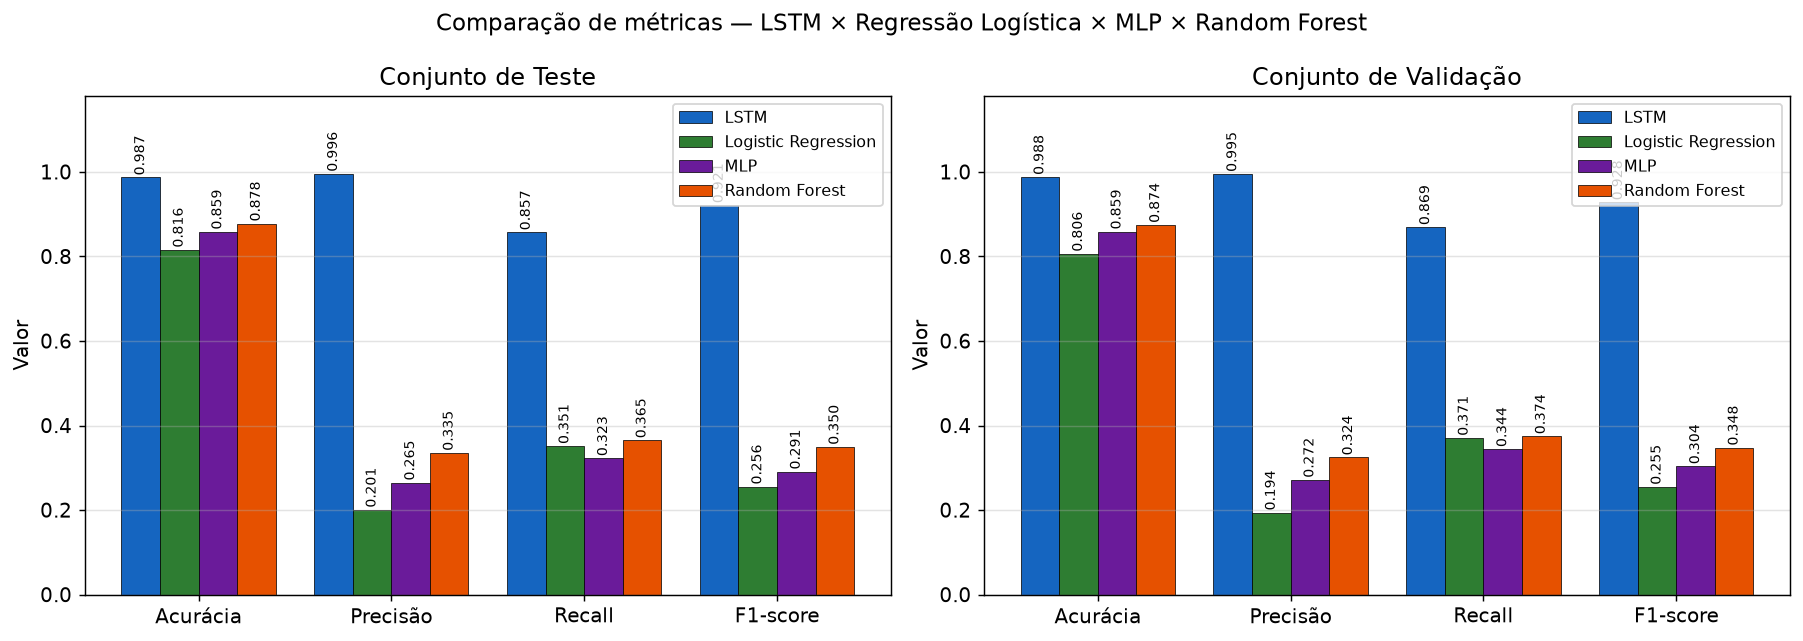

In [8]:
METRIC_KEYS   = ['accuracy', 'precision', 'recall', 'f1_score']
METRIC_LABELS = ['Acurácia', 'Precisão', 'Recall', 'F1-score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de métricas — LSTM × Regressão Logística × MLP × Random Forest', fontsize=13)

for ax, split_key, split_label in zip(axes, ['test', 'validation'], ['Teste', 'Validação']):
    x = np.arange(len(METRIC_KEYS))
    width = 0.2
    n_models = len(models)
    for i, m in enumerate(models):
        vals = [m['metrics'][split_key][k] for k in METRIC_KEYS]
        bars = ax.bar(x + (i - (n_models - 1) / 2) * width, vals, width,
                      label=m['model_name'],
                      color=COLORS[m['model_name']],
                      edgecolor='black', linewidth=0.4)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_LABELS)
    ax.set_ylim(0, 1.18)
    ax.set_title(f'Conjunto de {split_label}')
    ax.set_ylabel('Valor')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'comp_metricas_barras_30d.png'), bbox_inches='tight')
plt.show()


## 5. Curvas ROC

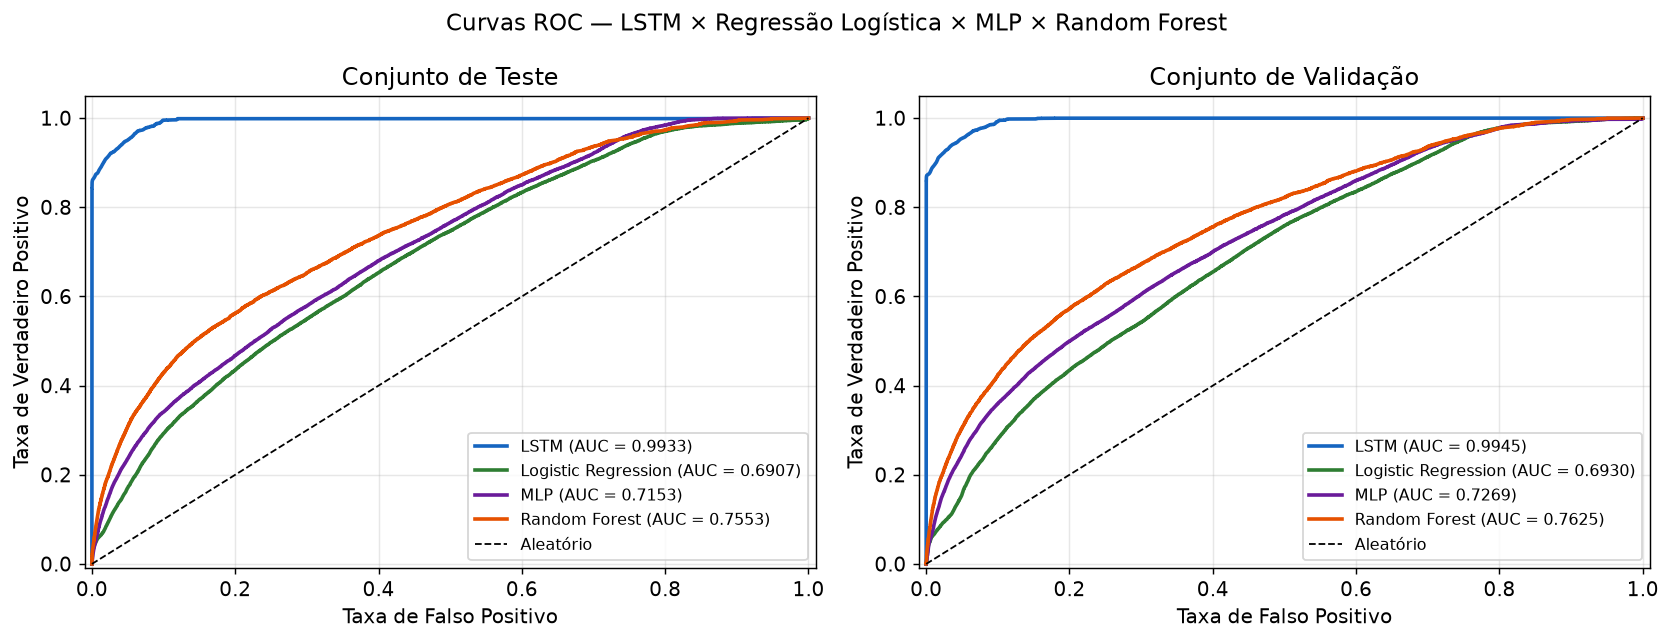

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Curvas ROC — LSTM × Regressão Logística × MLP × Random Forest', fontsize=13)

for ax, split_key, split_label in zip(axes, ['test', 'validation'], ['Teste', 'Validação']):
    for m in models:
        y_true  = m['predictions'][split_key]['y_true']
        y_proba = m['predictions'][split_key]['y_proba']
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORS[m['model_name']], lw=2,
                label=f"{m['model_name']} (AUC = {roc_auc:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel('Taxa de Falso Positivo')
    ax.set_ylabel('Taxa de Verdadeiro Positivo')
    ax.set_title(f'Conjunto de {split_label}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'comp_roc_30d.png'), bbox_inches='tight')
plt.show()


## 6. Curvas Precisão-Recall

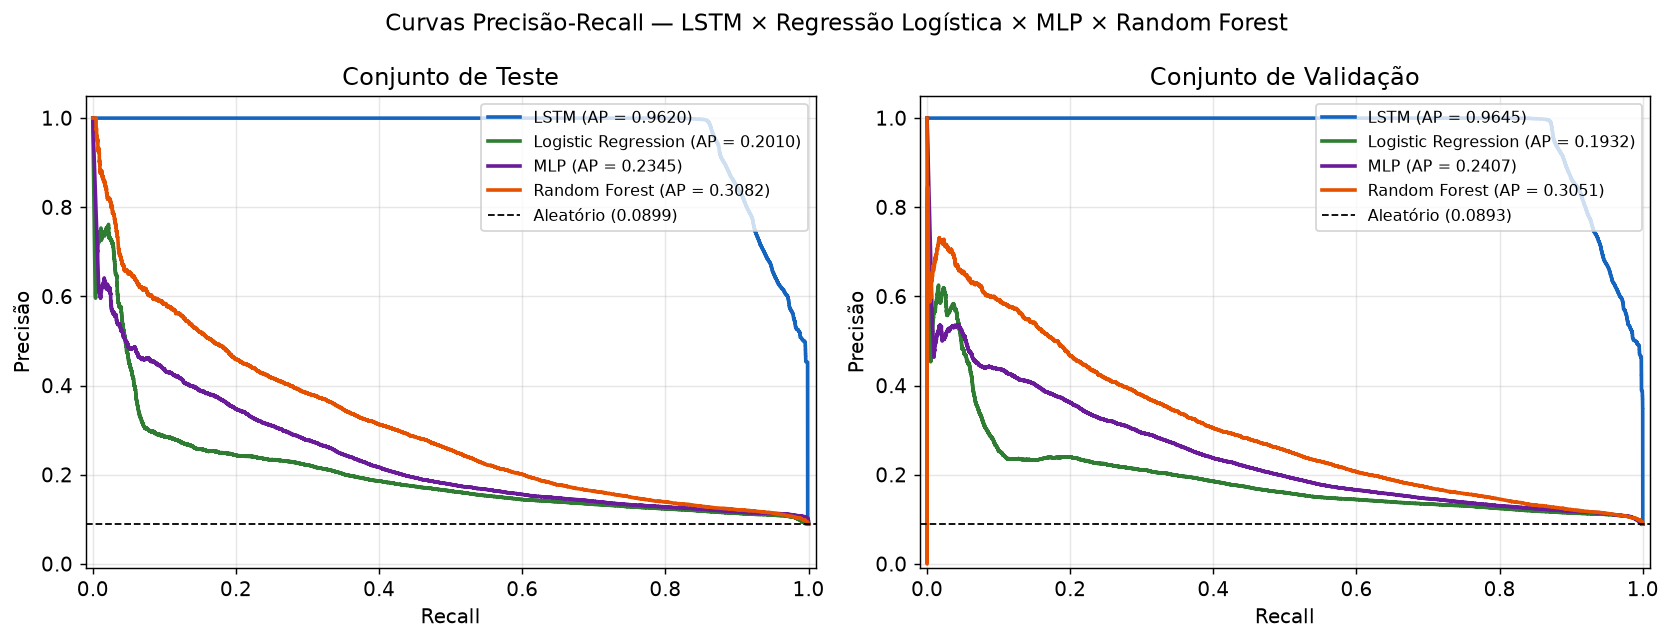

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Curvas Precisão-Recall — LSTM × Regressão Logística × MLP × Random Forest', fontsize=13)

for ax, split_key, split_label in zip(axes, ['test', 'validation'], ['Teste', 'Validação']):
    for m in models:
        y_true  = m['predictions'][split_key]['y_true']
        y_proba = m['predictions'][split_key]['y_proba']
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        ax.plot(rec, prec, color=COLORS[m['model_name']], lw=2,
                label=f"{m['model_name']} (AP = {ap:.4f})")
    # Linha de base (prevalência)
    prevalencia = float(y_true.mean())
    ax.axhline(prevalencia, color='k', linestyle='--', lw=1,
               label=f'Aleatório ({prevalencia:.4f})')
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precisão')
    ax.set_title(f'Conjunto de {split_label}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'comp_pr_30d.png'), bbox_inches='tight')
plt.show()


## 7. Matrizes de confusão (conjunto de teste)

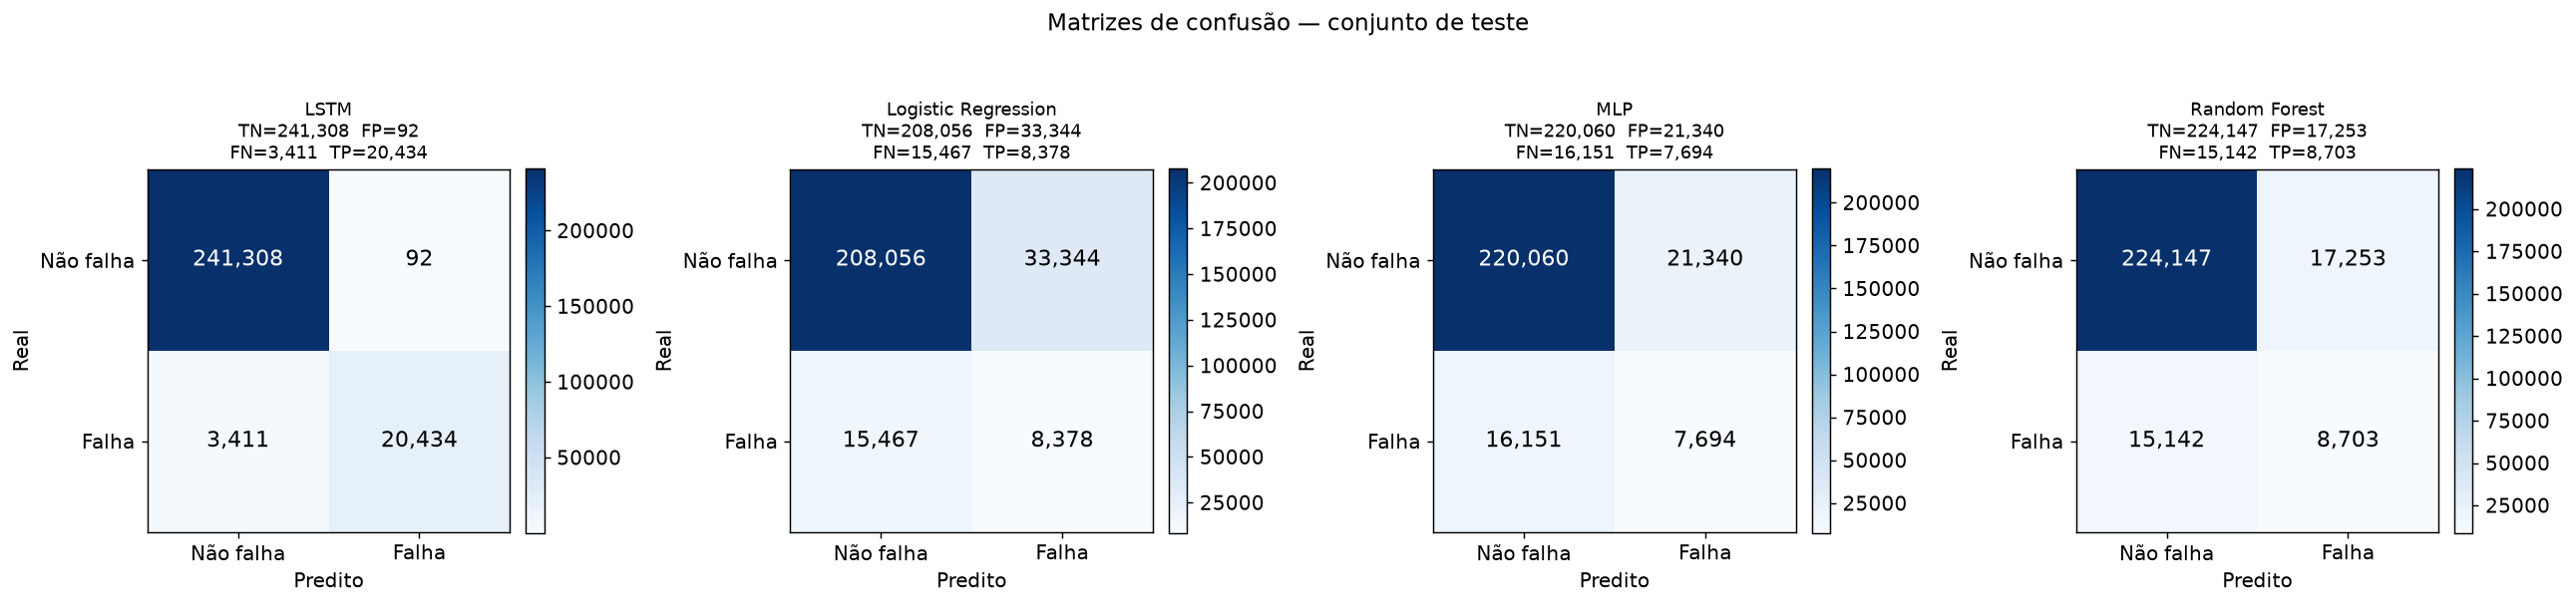

In [11]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Matrizes de confusão — conjunto de teste', fontsize=13)

for ax, m in zip(axes, models):
    cm = m['metrics']['test']['confusion_matrix']
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    tick_marks = [0, 1]
    labels = ['Não falha', 'Falha']
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}',
                    ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > thresh else 'black')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{m['model_name']}\n"
                 f"TN={tn:,}  FP={fp:,}\nFN={fn:,}  TP={tp:,}", fontsize=10)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'comp_confusao_30d.png'), bbox_inches='tight')
plt.show()


## 8. Histórico de perda do LSTM

Evolução da perda (BCE ponderado) ao longo dos epochs de treinamento do LSTM.

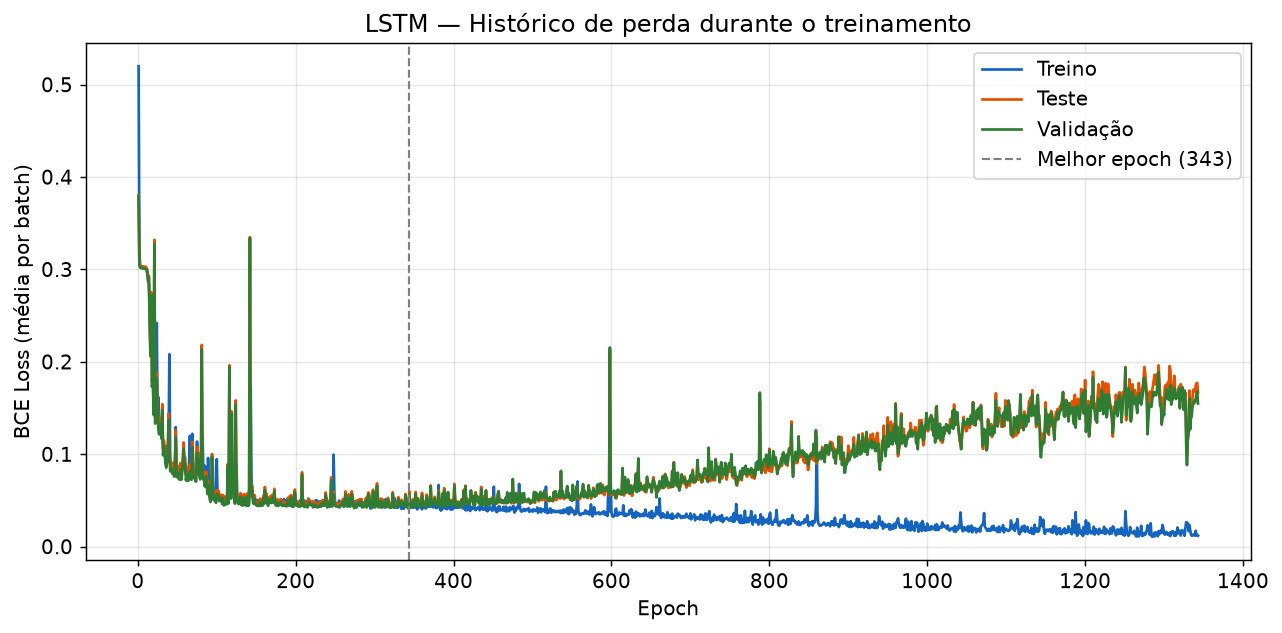

In [12]:
lh = lstm['loss_history']
epochs = np.arange(1, len(lh['train']) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, lh['train'],      label='Treino',     color='#1565C0', lw=1.5)
ax.plot(epochs, lh['test'],       label='Teste',      color='#E65100', lw=1.5)
ax.plot(epochs, lh['validation'], label='Validação',  color='#2E7D32', lw=1.5)

best_ep = ckpt['best_epoch']
ax.axvline(best_ep, color='gray', linestyle='--', lw=1.2,
           label=f'Melhor epoch ({best_ep})')

ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss (média por batch)')
ax.set_title('LSTM — Histórico de perda durante o treinamento')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'lstm_loss_history_30d.png'), bbox_inches='tight')
plt.show()


## 9. Comparação de tempo de treinamento

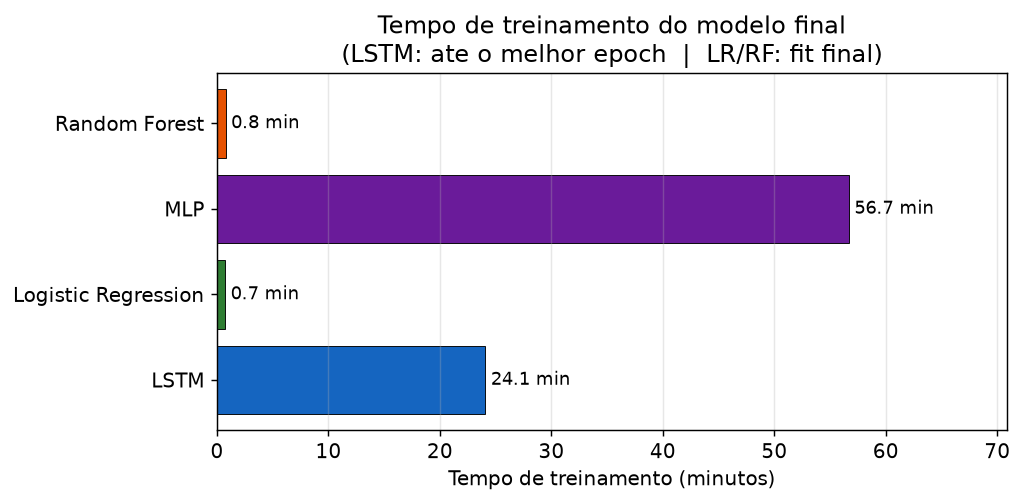

Tempos de treinamento:
  LSTM                     : 24.1 min
  Logistic Regression      : 0.7 min
  MLP                      : 56.7 min
  Random Forest            : 0.8 min


In [13]:
model_names = [m['model_name'] for m in models]
train_times = [m['train_time_seconds'] / 60 for m in models]  # minutos

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(model_names, train_times,
               color=[COLORS[n] for n in model_names],
               edgecolor='black', linewidth=0.5)
for bar, t in zip(bars, train_times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{t:.1f} min', va='center', fontsize=10)

ax.set_xlabel('Tempo de treinamento (minutos)')
ax.set_title('Tempo de treinamento do modelo final\n'
             '(LSTM: ate o melhor epoch  |  LR/RF: fit final)')
ax.set_xlim(0, max(train_times) * 1.25)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'comp_tempo_treino_30d.png'), bbox_inches='tight')
plt.show()

print('Tempos de treinamento:')
for name, t in zip(model_names, train_times):
    print(f'  {name:<25}: {t:.1f} min')


## 10. Top features do Random Forest

O Random Forest expõe a importância de cada feature de janela deslizante —
útil para discutir quais atributos SMART são mais informativos.

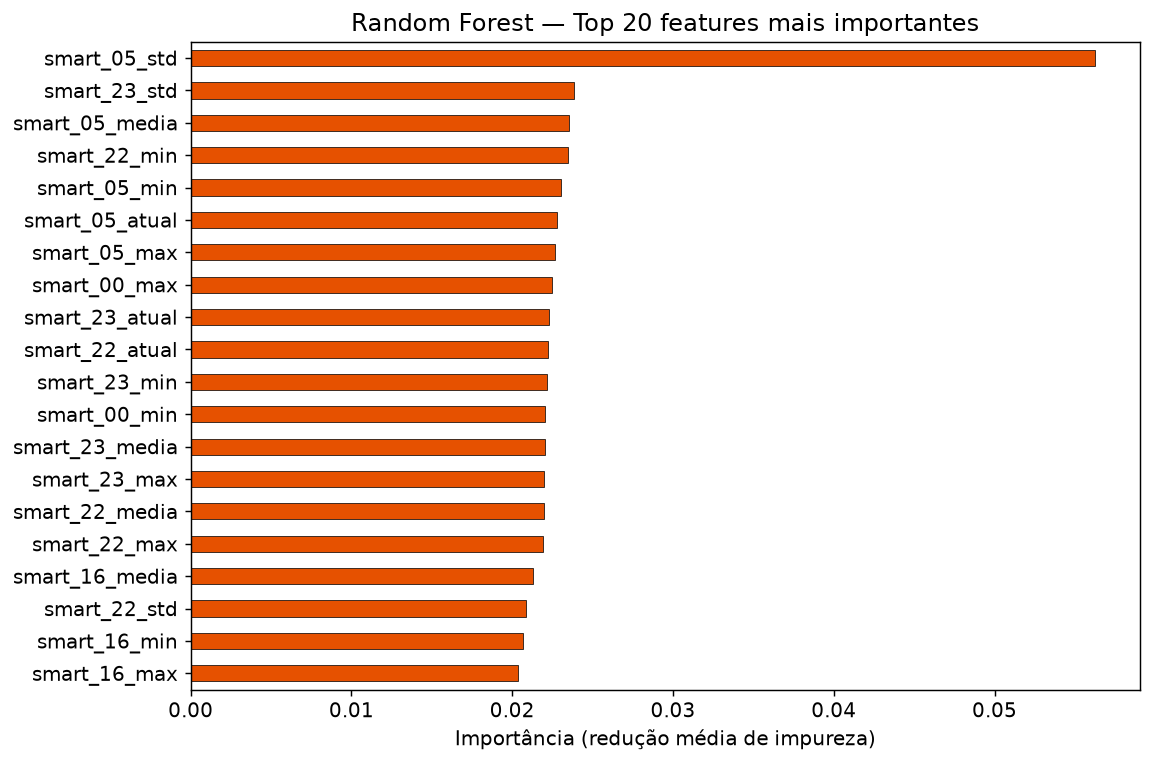

In [14]:
import pandas as pd

importances = pd.Series(rf['feature_importances']).sort_values(ascending=False)
top_n = 20

fig, ax = plt.subplots(figsize=(9, 6))
importances.head(top_n)[::-1].plot(
    kind='barh', ax=ax,
    color='#E65100', edgecolor='black', linewidth=0.4)
ax.set_title(f'Random Forest — Top {top_n} features mais importantes')
ax.set_xlabel('Importância (redução média de impureza)')
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTPUT_DIR, 'comp_rf_feature_importance_30d.png'), bbox_inches='tight')
plt.show()


## 11. Análise por disco (visão operacional)

As métricas anteriores são **por amostra** `(disco, dia)`. Operacionalmente,
porém, um disco é "salvo" se houver **um único alarme a tempo** dentro da sua
janela positiva (os dias com `y_true == 1`, isto é, os últimos
`CONTAMINATION_LEVEL` dias válidos antes da falha) — a métrica por amostra
subestima essa utilidade prática. Esta seção usa apenas as predições já salvas
(sem re-treino), no conjunto de **teste** e no **limiar oficial** de cada
modelo (o limiar ótimo escolhido na validação, já aplicado na Seção 3):

- **Taxa de detecção por disco:** fração de discos com pelo menos uma predição
  positiva dentro da janela positiva real.
- **Falsos alarmes por disco:** média e mediana, por disco, de dias com
  predição positiva fora da janela positiva.
- **Antecedência média:** entre os discos detectados, média de
  (dia da falha − primeiro alarme dentro da janela positiva), em dias.
  O último dia válido de cada disco é o dia da falha.


In [15]:
# As predicoes salvas de LR/MLP/RF trazem disco_id/timestep; as do LSTM
# (geradas na Secao 2) seguem a ordem disco-a-disco dos timesteps validos,
# entao reconstruimos os indices a partir da mascara de teste.
lstm_test_disco_id = np.repeat(np.arange(3740, 4541), test_valid_sizes.astype(int))
lstm_test_timestep = np.concatenate([np.arange(int(v)) for v in test_valid_sizes])
assert len(lstm_test_disco_id) == len(lstm['predictions']['test']['y_true'])


def analise_por_disco(preds, disco_id_arr, timestep_arr):
    y_true = np.asarray(preds['y_true']).astype(int)
    y_pred = np.asarray(preds['y_pred']).astype(int)

    detectados = 0
    antecedencias = []
    falsos_alarmes = []

    for d in np.unique(disco_id_arr):
        sel = disco_id_arr == d
        yt, yp, ts = y_true[sel], y_pred[sel], timestep_arr[sel]
        dia_falha = int(ts.max())          # ultimo dia valido = dia da falha

        janela = yt == 1                    # janela positiva real do disco
        alarmes_na_janela = ts[janela & (yp == 1)]
        if len(alarmes_na_janela) > 0:
            detectados += 1
            antecedencias.append(dia_falha - int(alarmes_na_janela.min()))

        falsos_alarmes.append(int(((~janela) & (yp == 1)).sum()))

    n_discos = len(np.unique(disco_id_arr))
    fa = np.array(falsos_alarmes)
    return {
        'taxa_deteccao': detectados / n_discos,
        'fa_media': float(fa.mean()),
        'fa_mediana': float(np.median(fa)),
        'antecedencia_media': float(np.mean(antecedencias)) if antecedencias else float('nan'),
        'n_discos': n_discos,
    }


header = (f"{'Modelo':<22}{'Detecção/disco':>15}{'FA média':>10}"
          f"{'FA mediana':>12}{'Antecedência':>14}")
print(header)
print('-' * len(header))
for m in models:
    preds = m['predictions']['test']
    if 'disco_id' in preds:
        d_arr = np.asarray(preds['disco_id'])
        t_arr = np.asarray(preds['timestep'])
    else:   # LSTM
        d_arr, t_arr = lstm_test_disco_id, lstm_test_timestep
    r = analise_por_disco(preds, d_arr, t_arr)
    print(f"{m['model_name']:<22}{r['taxa_deteccao']:>15.3f}{r['fa_media']:>10.2f}"
          f"{r['fa_mediana']:>12.1f}{r['antecedencia_media']:>11.2f} d")


Modelo                 Detecção/disco  FA média  FA mediana  Antecedência
-------------------------------------------------------------------------
LSTM                            0.859      0.11         0.0      28.70 d


Logistic Regression             0.584     41.63         4.0      19.23 d
MLP                             0.650     26.64         3.0      17.05 d


Random Forest                   0.673     21.54         0.0      16.61 d


A leitura prática: mesmo um modelo com F1 por amostra modesto pode salvar a
maioria dos discos se acertar **ao menos um dia** da janela de 7 dias — a taxa
de detecção por disco tende a ser bem maior que o recall por amostra. O custo
operacional aparece nos falsos alarmes por disco (trocas/inspeções
desnecessárias), e a antecedência indica quantos dias de folga a equipe teria
para agir antes da falha.


## Curvas de aprendizagem (modelos tabulares)

Sobrepoe as curvas de aprendizagem (Average Precision em validacao cruzada x
tamanho do treino) de LR, MLP e RF, lidas dos `.pkl` gerados pelos notebooks de
treino. Linha cheia = validacao (CV); tracejada = treino. O **LSTM** nao tem
curva desse tipo (e sequencial, nao tabular) - a sua curva de treino e o
**historico de perda por epoca** mostrado na secao anterior.

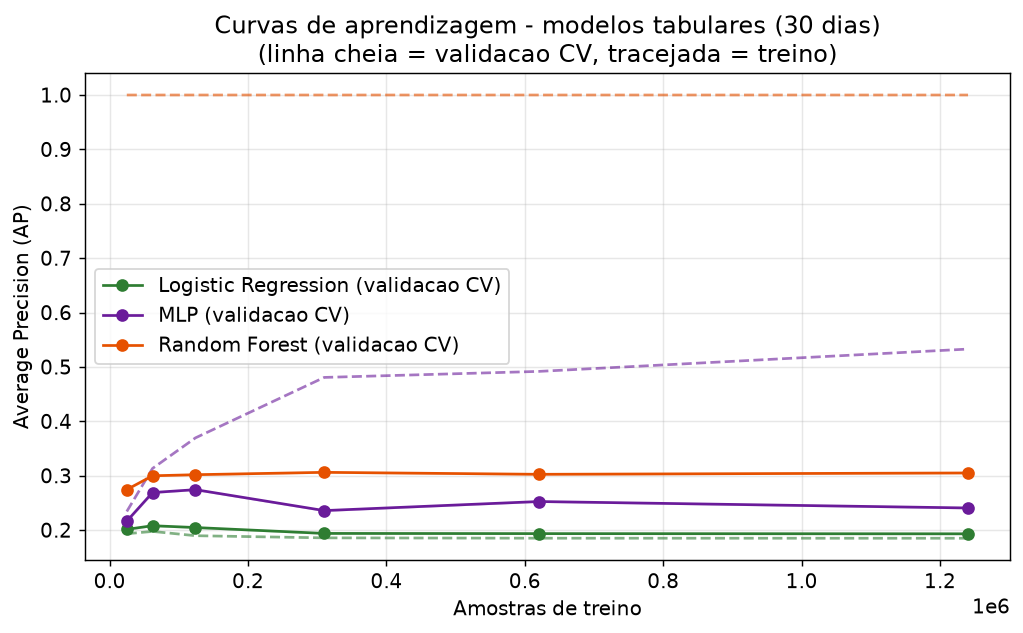

In [16]:
# Curvas de aprendizagem consolidadas (le os .pkl salvos pelos notebooks de treino)
import os, pickle
import matplotlib.pyplot as plt

_lc_files = [('Logistic Regression', 'lr_learning_curve_30d.pkl'),
             ('MLP', 'mlp_learning_curve_30d.pkl'),
             ('Random Forest', 'rf_learning_curve_30d.pkl')]
_lcs = []
for _nome, _arq in _lc_files:
    _p = os.path.join(OUTPUT_DIR, _arq)
    if os.path.exists(_p):
        with open(_p, 'rb') as _f:
            _lcs.append((_nome, pickle.load(_f)))
    else:
        print('AVISO: nao encontrei', _arq, '- rode o notebook de treino correspondente para gera-lo.')

if _lcs:
    fig, ax = plt.subplots(figsize=(8, 5))
    for _nome, _d in _lcs:
        _c = COLORS.get(_nome)
        ax.plot(_d['train_sizes'], _d['val_mean'], 'o-', color=_c, label=f'{_nome} (validacao CV)')
        ax.fill_between(_d['train_sizes'], _d['val_mean'] - _d['val_std'],
                        _d['val_mean'] + _d['val_std'], alpha=0.12, color=_c)
        ax.plot(_d['train_sizes'], _d['train_mean'], '--', color=_c, alpha=0.6)
    ax.set_xlabel('Amostras de treino')
    ax.set_ylabel('Average Precision (AP)')
    ax.set_title('Curvas de aprendizagem - modelos tabulares (30 dias)\n'
                 '(linha cheia = validacao CV, tracejada = treino)')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(os.path.join(OUTPUT_DIR, 'comp_learning_curves_30d.png'), bbox_inches='tight')
    plt.show()
else:
    print('Nenhuma curva encontrada - execute os notebooks de treino (eles geram os *_learning_curve*.pkl).')
